In [1]:
!pip -q install lightgbm xgboost openpyxl

In [2]:
import os
import json
import copy
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [3]:
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive'
OUTPUT_DIR = os.path.join(BASE_DIR, 'model_4_v3_hybrid_expert_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
DATA_FILE = os.path.join(BASE_DIR, 'model_ready_category_dataset.csv')

MODEL_1_FILE = os.path.join(BASE_DIR, 'model_1_statistical_baseline_outputs', 'model_1_test_results.csv')
MODEL_2_FILE = os.path.join(BASE_DIR, 'model_2_tree_based_outputs', 'model_2_test_results.csv')
MODEL_3_FILE = os.path.join(BASE_DIR, 'model_3_lstm_outputs', 'model_3_test_results.csv')

print('Output directory:', OUTPUT_DIR)
print('Main data file:', DATA_FILE)
print('Model 1 file:', MODEL_1_FILE, '| exists:', os.path.exists(MODEL_1_FILE))
print('Model 2 file:', MODEL_2_FILE, '| exists:', os.path.exists(MODEL_2_FILE))
print('Model 3 file:', MODEL_3_FILE, '| exists:', os.path.exists(MODEL_3_FILE))

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f'Main category dataset not found at: {DATA_FILE}.\n'
        'Edit DATA_FILE in Section 2 to the exact filename/path in your Drive.'
    )

Output directory: /content/drive/MyDrive/model_4_v3_hybrid_expert_outputs
Main data file: /content/drive/MyDrive/model_ready_category_dataset.csv
Model 1 file: /content/drive/MyDrive/model_1_statistical_baseline_outputs/model_1_test_results.csv | exists: True
Model 2 file: /content/drive/MyDrive/model_2_tree_based_outputs/model_2_test_results.csv | exists: True
Model 3 file: /content/drive/MyDrive/model_3_lstm_outputs/model_3_test_results.csv | exists: True


In [5]:
category_df_raw = pd.read_csv(DATA_FILE)

print('Raw shape:', category_df_raw.shape)
print('Raw columns:', list(category_df_raw.columns))

DATE_CANDIDATES = ['week_start', 'week', 'Week', 'date', 'Date', 'period', 'Period']
CATEGORY_CANDIDATES = ['Product Category', 'product_category', 'Category', 'category', 'PRODUCT_CATEGORY']
TARGET_CANDIDATES = ['weekly_quantity', 'quantity', 'Quantity', 'qty', 'Qty', 'sales', 'Sales']

DATE_COL_ORIGINAL = next((c for c in DATE_CANDIDATES if c in category_df_raw.columns), None)
CATEGORY_COL_ORIGINAL = next((c for c in CATEGORY_CANDIDATES if c in category_df_raw.columns), None)
TARGET_COL_ORIGINAL = next((c for c in TARGET_CANDIDATES if c in category_df_raw.columns), None)

if DATE_COL_ORIGINAL is None:
    raise ValueError(f'Date column not found. Available columns: {list(category_df_raw.columns)}')
if CATEGORY_COL_ORIGINAL is None:
    raise ValueError(f'Category column not found. Available columns: {list(category_df_raw.columns)}')
if TARGET_COL_ORIGINAL is None:
    raise ValueError(f'Target quantity column not found. Available columns: {list(category_df_raw.columns)}')

category_df = category_df_raw.rename(columns={
    DATE_COL_ORIGINAL: 'week_start',
    CATEGORY_COL_ORIGINAL: 'Product Category',
    TARGET_COL_ORIGINAL: 'weekly_quantity'
}).copy()

category_df['week_start'] = pd.to_datetime(category_df['week_start'])
category_df['week_start'] = category_df['week_start'] - pd.to_timedelta(category_df['week_start'].dt.weekday, unit='D')
category_df['Product Category'] = category_df['Product Category'].astype(str)
category_df['weekly_quantity'] = pd.to_numeric(category_df['weekly_quantity'], errors='coerce').fillna(0)
category_df['weekly_quantity'] = category_df['weekly_quantity'].clip(lower=0)

category_df = (
    category_df
    .groupby(['Product Category', 'week_start'], as_index=False)
    .agg(weekly_quantity=('weekly_quantity', 'sum'))
)

all_weeks = pd.date_range(category_df['week_start'].min(), category_df['week_start'].max(), freq='W-MON')
all_categories = category_df[['Product Category']].drop_duplicates()

category_panel = (
    all_categories.assign(key=1)
    .merge(pd.DataFrame({'week_start': all_weeks, 'key': 1}), on='key')
    .drop(columns='key')
    .merge(category_df, on=['Product Category', 'week_start'], how='left')
)
category_panel['weekly_quantity'] = category_panel['weekly_quantity'].fillna(0)
category_panel = category_panel.sort_values(['Product Category', 'week_start']).reset_index(drop=True)

category_panel.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_input_category_panel.csv'), index=False, encoding='utf-8-sig')

print('Standardized panel shape:', category_panel.shape)
print('Categories:', category_panel['Product Category'].nunique())
print('Weeks:', category_panel['week_start'].nunique())
print('Date range:', category_panel['week_start'].min(), 'to', category_panel['week_start'].max())
print('Total demand:', category_panel['weekly_quantity'].sum())

Raw shape: (6200, 44)
Raw columns: ['Product Category', 'week_start', 'weekly_quantity', 'weekly_revenue', 'transaction_count', 'unique_skus', 'unique_customers', 'avg_unit_price', 'avg_gross_margin_pct', 'negative_margin_share', 'from_china_share', 'from_india_share', 'year', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'split_val_4_test_4', 'split_val_4_test_8', 'split_val_4_test_12', 'split_val_8_test_4', 'split_val_8_test_8', 'split_val_8_test_12', 'split_val_12_test_4', 'split_val_12_test_8', 'split_val_12_test_12']
Standardized panel shape: (6200, 3)
Categories: 40
Weeks: 155
Date range: 2023-01-09 00:00:00 to 2025-12-22 00:00:00
Total demand: 530935.0


In [6]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    result = np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)
    return np.mean(result) * 100


def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)

    if len(y_train) <= seasonality:
        scale = np.mean(np.abs(y_train - np.mean(y_train))) if len(y_train) > 0 else 1
    else:
        scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))

    if scale == 0 or np.isnan(scale):
        scale = np.mean(np.abs(y_train)) if np.mean(np.abs(y_train)) > 0 else 1

    return np.mean(np.abs(y_true - y_pred)) / scale


def evaluate_forecast(y_true, y_pred, y_train):
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)
    return {
        'MAE': mae(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'MASE': mase(y_true, y_pred, y_train, seasonality=1)
    }

In [7]:
def add_forecasting_features(df):
    data = df.copy().sort_values(['Product Category', 'week_start'])

    data['week_of_year'] = data['week_start'].dt.isocalendar().week.astype(int)
    data['month'] = data['week_start'].dt.month.astype(int)
    data['quarter'] = data['week_start'].dt.quarter.astype(int)
    data['year'] = data['week_start'].dt.year.astype(int)

    data['week_sin'] = np.sin(2 * np.pi * data['week_of_year'] / 52)
    data['week_cos'] = np.cos(2 * np.pi * data['week_of_year'] / 52)
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    lag_values = [1, 2, 4, 8, 12, 26, 52]
    rolling_windows = [4, 8, 12, 26]

    for lag in lag_values:
        data[f'lag_{lag}'] = data.groupby('Product Category')['weekly_quantity'].shift(lag)

    for window in rolling_windows:
        shifted = data.groupby('Product Category')['weekly_quantity'].shift(1)
        data[f'rolling_mean_{window}'] = shifted.groupby(data['Product Category']).rolling(window).mean().reset_index(level=0, drop=True)
        data[f'rolling_std_{window}'] = shifted.groupby(data['Product Category']).rolling(window).std().reset_index(level=0, drop=True)
        data[f'rolling_max_{window}'] = shifted.groupby(data['Product Category']).rolling(window).max().reset_index(level=0, drop=True)
        data[f'recent_zero_ratio_{window}'] = shifted.groupby(data['Product Category']).rolling(window).apply(lambda x: np.mean(np.asarray(x) == 0), raw=False).reset_index(level=0, drop=True)
        data[f'recent_positive_ratio_{window}'] = shifted.groupby(data['Product Category']).rolling(window).apply(lambda x: np.mean(np.asarray(x) > 0), raw=False).reset_index(level=0, drop=True)

    streak_values = []
    for _, group in data.groupby('Product Category', sort=False):
        shifted_values = group['weekly_quantity'].shift(1).fillna(0).values
        streak = 0
        local = []
        for value in shifted_values:
            if value == 0:
                streak += 1
            else:
                streak = 0
            local.append(streak)
        streak_values.extend(local)
    data['zero_streak'] = streak_values

    data = data.replace([np.inf, -np.inf], np.nan).fillna(0)
    return data


feature_df = add_forecasting_features(category_panel)

BASE_FEATURE_COLS = [
    c for c in feature_df.columns
    if c not in ['Product Category', 'week_start', 'weekly_quantity']
    and pd.api.types.is_numeric_dtype(feature_df[c])
]

feature_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_forecasting_feature_dataset.csv'), index=False, encoding='utf-8-sig')

print('Number of forecasting features:', len(BASE_FEATURE_COLS))
print(BASE_FEATURE_COLS)

Number of forecasting features: 36
['week_of_year', 'month', 'quarter', 'year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_max_4', 'recent_zero_ratio_4', 'recent_positive_ratio_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_max_8', 'recent_zero_ratio_8', 'recent_positive_ratio_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_max_12', 'recent_zero_ratio_12', 'recent_positive_ratio_12', 'rolling_mean_26', 'rolling_std_26', 'rolling_max_26', 'recent_zero_ratio_26', 'recent_positive_ratio_26', 'zero_streak']


In [8]:
def average_demand_interval(values):
    values = np.asarray(values, dtype=float)
    positive_idx = np.where(values > 0)[0]
    if len(positive_idx) <= 1:
        return len(values)
    return np.mean(np.diff(positive_idx))


def trend_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 3 or np.sum(values) == 0:
        return 0
    x = np.arange(len(values))
    return np.polyfit(x, values, 1)[0]


def seasonality_strength(values, dates):
    temp = pd.DataFrame({'y': values, 'date': pd.to_datetime(dates)})
    temp['month'] = temp['date'].dt.month
    monthly = temp.groupby('month')['y'].mean()
    if monthly.mean() == 0 or np.isnan(monthly.mean()):
        return 0
    return monthly.std() / monthly.mean()


def build_category_behavior_profiles(train_history_df):
    rows = []

    for category, group in train_history_df.groupby('Product Category'):
        group = group.sort_values('week_start')
        y = group['weekly_quantity'].values.astype(float)
        positive_y = y[y > 0]

        mean_demand = np.mean(y) if len(y) else 0
        median_demand = np.median(y) if len(y) else 0
        std_demand = np.std(y, ddof=1) if len(y) > 1 else 0
        cv = std_demand / mean_demand if mean_demand > 0 else 0
        cv2 = cv ** 2
        max_demand = np.max(y) if len(y) else 0
        spike_ratio = max_demand / mean_demand if mean_demand > 0 else 0
        zero_ratio = np.mean(y == 0) if len(y) else 0
        positive_ratio = np.mean(y > 0) if len(y) else 0
        adi = average_demand_interval(y)
        intermittency_score = zero_ratio * adi

        if adi < 1.32 and cv2 < 0.49:
            demand_class = 'smooth'
        elif adi >= 1.32 and cv2 < 0.49:
            demand_class = 'intermittent'
        elif adi < 1.32 and cv2 >= 0.49:
            demand_class = 'erratic'
        else:
            demand_class = 'lumpy'

        rows.append({
            'Product Category': category,
            'mean_demand': mean_demand,
            'median_demand': median_demand,
            'std_demand': std_demand,
            'cv': cv,
            'cv2': cv2,
            'zero_ratio': zero_ratio,
            'positive_ratio': positive_ratio,
            'max_demand': max_demand,
            'spike_ratio': spike_ratio,
            'nonzero_mean': np.mean(positive_y) if len(positive_y) else 0,
            'nonzero_std': np.std(positive_y, ddof=1) if len(positive_y) > 1 else 0,
            'ADI': adi,
            'intermittency_score': intermittency_score,
            'seasonality_strength': seasonality_strength(y, group['week_start'].values),
            'trend_slope': trend_slope(y),
            'recent_4_mean': np.mean(y[-4:]) if len(y) >= 4 else mean_demand,
            'recent_8_mean': np.mean(y[-8:]) if len(y) >= 8 else mean_demand,
            'recent_12_mean': np.mean(y[-12:]) if len(y) >= 12 else mean_demand,
            'demand_class': demand_class
        })

    profile = pd.DataFrame(rows)
    demand_class_map = {'smooth': 0, 'intermittent': 1, 'erratic': 2, 'lumpy': 3}
    profile['demand_class_encoded'] = profile['demand_class'].map(demand_class_map).fillna(3)
    return profile


CLUSTER_FEATURE_COLS = [
    'mean_demand', 'median_demand', 'std_demand', 'cv', 'cv2',
    'zero_ratio', 'positive_ratio', 'max_demand', 'spike_ratio',
    'nonzero_mean', 'nonzero_std', 'ADI', 'intermittency_score',
    'seasonality_strength', 'trend_slope',
    'recent_4_mean', 'recent_8_mean', 'recent_12_mean',
    'demand_class_encoded'
]

In [9]:

def prepare_cluster_matrix(profile_df):
    X = profile_df[CLUSTER_FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0).copy()

    log_cols = [
        'mean_demand', 'median_demand', 'std_demand', 'cv', 'cv2',
        'max_demand', 'spike_ratio', 'nonzero_mean', 'nonzero_std',
        'ADI', 'intermittency_score', 'recent_4_mean', 'recent_8_mean', 'recent_12_mean'
    ]

    for col in log_cols:
        X[col] = np.log1p(np.maximum(X[col], 0))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


def run_clustering_experiments(profile_df):
    X_scaled = prepare_cluster_matrix(profile_df)

    k_candidates = [2, 3, 4, 5, 6, 7, 8]
    algorithms = ['kmeans', 'agglomerative', 'gmm']

    results = []
    labels_store = {}

    for algorithm in algorithms:
        for k in k_candidates:
            if k >= len(profile_df):
                continue
            try:
                if algorithm == 'kmeans':
                    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
                    labels = model.fit_predict(X_scaled)
                elif algorithm == 'agglomerative':
                    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
                    labels = model.fit_predict(X_scaled)
                elif algorithm == 'gmm':
                    model = GaussianMixture(n_components=k, random_state=RANDOM_STATE, covariance_type='full')
                    labels = model.fit_predict(X_scaled)

                if len(np.unique(labels)) < 2:
                    continue

                sil = silhouette_score(X_scaled, labels)
                db = davies_bouldin_score(X_scaled, labels)
                ch = calinski_harabasz_score(X_scaled, labels)

                results.append({
                    'algorithm': algorithm,
                    'k': k,
                    'silhouette': sil,
                    'davies_bouldin': db,
                    'calinski_harabasz': ch
                })
                labels_store[(algorithm, k)] = labels
            except Exception as e:
                results.append({
                    'algorithm': algorithm,
                    'k': k,
                    'silhouette': np.nan,
                    'davies_bouldin': np.nan,
                    'calinski_harabasz': np.nan,
                    'error': str(e)
                })

    results_df = pd.DataFrame(results).dropna(subset=['silhouette', 'davies_bouldin', 'calinski_harabasz'])

    results_df['rank_silhouette'] = results_df['silhouette'].rank(ascending=False)
    results_df['rank_davies_bouldin'] = results_df['davies_bouldin'].rank(ascending=True)
    results_df['rank_calinski'] = results_df['calinski_harabasz'].rank(ascending=False)
    results_df['combined_rank'] = results_df['rank_silhouette'] + results_df['rank_davies_bouldin'] + results_df['rank_calinski']
    results_df = results_df.sort_values('combined_rank').reset_index(drop=True)

    best = results_df.iloc[0].to_dict()
    best_labels = labels_store[(best['algorithm'], int(best['k']))]

    return results_df, best, best_labels

In [11]:
class SeasonalNaiveExpert:
    def __init__(self, seasonality=52):
        self.seasonality = seasonality
        self.train_series_by_category = {}

    def fit(self, train_df):
        self.train_series_by_category = {
            cat: g.sort_values('week_start')['weekly_quantity'].values.astype(float)
            for cat, g in train_df.groupby('Product Category')
        }
        return self

    def predict(self, future_df):
        preds = []
        for cat, g in future_df.groupby('Product Category'):
            y = self.train_series_by_category.get(cat, np.array([0.0]))
            n = len(g)
            local_preds = []
            for i in range(n):
                if len(y) >= self.seasonality:
                    pred = y[-self.seasonality + (i % self.seasonality)] if self.seasonality - (i % self.seasonality) <= len(y) else y[-1]
                elif len(y) > 0:
                    pred = y[-1]
                else:
                    pred = 0
                local_preds.append(max(pred, 0))
            preds.extend(local_preds)
        return np.array(preds)


class MovingAverageExpert:
    def __init__(self, window=4):
        self.window = window
        self.train_series_by_category = {}

    def fit(self, train_df):
        self.train_series_by_category = {
            cat: g.sort_values('week_start')['weekly_quantity'].values.astype(float)
            for cat, g in train_df.groupby('Product Category')
        }
        return self

    def predict(self, future_df):
        preds = []
        for cat, g in future_df.groupby('Product Category'):
            y = self.train_series_by_category.get(cat, np.array([0.0]))
            pred = np.mean(y[-self.window:]) if len(y) > 0 else 0
            preds.extend([max(pred, 0)] * len(g))
        return np.array(preds)


class CrostonExpert:
    def __init__(self, alpha=0.1, variant='croston'):
        self.alpha = alpha
        self.variant = variant
        self.forecast_by_category = {}

    def _croston_forecast(self, y):
        y = np.asarray(y, dtype=float)
        nonzero_idx = np.where(y > 0)[0]
        if len(nonzero_idx) == 0:
            return 0.0

        z = y[nonzero_idx[0]]
        p = max(nonzero_idx[0] + 1, 1)
        last_nonzero = nonzero_idx[0]

        for idx in nonzero_idx[1:]:
            interval = idx - last_nonzero
            z = self.alpha * y[idx] + (1 - self.alpha) * z
            p = self.alpha * interval + (1 - self.alpha) * p
            last_nonzero = idx

        forecast = z / p if p > 0 else 0

        if self.variant == 'sba':
            forecast = (1 - self.alpha / 2) * forecast

        return max(float(forecast), 0)

    def fit(self, train_df):
        for cat, g in train_df.groupby('Product Category'):
            y = g.sort_values('week_start')['weekly_quantity'].values.astype(float)
            self.forecast_by_category[cat] = self._croston_forecast(y)
        return self

    def predict(self, future_df):
        preds = []
        for cat, g in future_df.groupby('Product Category'):
            pred = self.forecast_by_category.get(cat, 0.0)
            preds.extend([pred] * len(g))
        return np.array(preds)


class TSBExpert:
    def __init__(self, alpha=0.1, beta=0.1):
        self.alpha = alpha
        self.beta = beta
        self.forecast_by_category = {}

    def _tsb_forecast(self, y):
        y = np.asarray(y, dtype=float)
        if len(y) == 0:
            return 0.0

        occurrence = (y > 0).astype(float)
        positive_values = y[y > 0]
        z = positive_values[0] if len(positive_values) > 0 else 0.0
        p = occurrence[0]

        for t in range(len(y)):
            p = self.beta * occurrence[t] + (1 - self.beta) * p
            if y[t] > 0:
                z = self.alpha * y[t] + (1 - self.alpha) * z

        return max(float(p * z), 0)

    def fit(self, train_df):
        for cat, g in train_df.groupby('Product Category'):
            y = g.sort_values('week_start')['weekly_quantity'].values.astype(float)
            self.forecast_by_category[cat] = self._tsb_forecast(y)
        return self

    def predict(self, future_df):
        preds = []
        for cat, g in future_df.groupby('Product Category'):
            pred = self.forecast_by_category.get(cat, 0.0)
            preds.extend([pred] * len(g))
        return np.array(preds)

In [13]:
def get_ml_experts():
    experts = {}

    experts['dummy_median'] = DummyRegressor(strategy='median')

    experts['extra_trees'] = ExtraTreesRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    experts['random_forest'] = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    experts['hist_gradient_boosting'] = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=0.3,
        random_state=RANDOM_STATE
    )

    experts['lightgbm_l2'] = LGBMRegressor(
        objective='regression',
        n_estimators=600,
        learning_rate=0.025,
        num_leaves=15,
        max_depth=5,
        min_child_samples=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )

    experts['lightgbm_tweedie'] = LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.3,
        n_estimators=600,
        learning_rate=0.025,
        num_leaves=15,
        max_depth=5,
        min_child_samples=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )

    experts['lightgbm_poisson'] = LGBMRegressor(
        objective='poisson',
        n_estimators=600,
        learning_rate=0.025,
        num_leaves=15,
        max_depth=5,
        min_child_samples=6,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )

    experts['xgboost_l2'] = XGBRegressor(
        n_estimators=600,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    experts['xgboost_poisson'] = XGBRegressor(
        n_estimators=600,
        learning_rate=0.025,
        max_depth=4,
        min_child_weight=4,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=1.0,
        objective='count:poisson',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return experts

def get_all_experts():
    experts = {}

    for alpha in [0.05, 0.1, 0.2, 0.3]:
        experts[f'croston_alpha_{alpha}'] = CrostonExpert(alpha=alpha, variant='croston')
        experts[f'sba_alpha_{alpha}'] = CrostonExpert(alpha=alpha, variant='sba')

    for alpha in [0.05, 0.1, 0.2]:
        for beta in [0.05, 0.1, 0.2]:
            experts[f'tsb_a{alpha}_b{beta}'] = TSBExpert(alpha=alpha, beta=beta)

    for window in [4, 8, 12, 26]:
        experts[f'moving_average_{window}'] = MovingAverageExpert(window=window)

    experts['seasonal_naive_52'] = SeasonalNaiveExpert(seasonality=52)

    experts.update(get_ml_experts())

    return experts

In [14]:
def is_statistical_expert(expert):
    return isinstance(expert, (CrostonExpert, TSBExpert, MovingAverageExpert, SeasonalNaiveExpert))


def fit_expert(expert, train_df, feature_cols):
    expert_copy = copy.deepcopy(expert)
    if is_statistical_expert(expert_copy):
        expert_copy.fit(train_df[['Product Category', 'week_start', 'weekly_quantity']])
    else:
        X_train = train_df[feature_cols].astype(float)
        y_train = train_df['weekly_quantity'].astype(float)
        expert_copy.fit(X_train, y_train)
    return expert_copy


def predict_expert(fitted_expert, future_df, feature_cols):
    if is_statistical_expert(fitted_expert):
        preds = fitted_expert.predict(future_df[['Product Category', 'week_start', 'weekly_quantity']])
    else:
        X_future = future_df[feature_cols].astype(float)
        preds = fitted_expert.predict(X_future)
    return np.maximum(np.asarray(preds, dtype=float), 0)


def evaluate_expert_by_category(train_df, eval_df, preds):
    category_metrics = []
    for category in eval_df['Product Category'].unique():
        idx = eval_df['Product Category'] == category
        eval_cat = eval_df[idx]
        pred_cat = preds[idx.values]
        train_cat = train_df[train_df['Product Category'] == category]

        if len(eval_cat) == 0 or len(train_cat) < 2:
            continue

        metrics = evaluate_forecast(
            eval_cat['weekly_quantity'].values,
            pred_cat,
            train_cat['weekly_quantity'].values
        )
        metrics['Product Category'] = category
        category_metrics.append(metrics)

    if not category_metrics:
        return {
            'MAE': np.nan,
            'RMSE': np.nan,
            'sMAPE': np.nan,
            'MASE': np.nan
        }

    metrics_df = pd.DataFrame(category_metrics)
    return metrics_df[['MAE', 'RMSE', 'sMAPE', 'MASE']].mean().to_dict()

In [15]:
def get_split_dates(df, validation_horizon, test_horizon):
    weeks = np.array(sorted(df['week_start'].unique()))
    test_start = pd.Timestamp(weeks[-test_horizon])
    validation_start = pd.Timestamp(weeks[-(validation_horizon + test_horizon)])
    return validation_start, test_start


split_scenarios = []
for val_horizon in [4, 8, 12]:
    for test_horizon in [4, 8, 12]:
        split_scenarios.append({
            'scenario': f'val_{val_horizon}_test_{test_horizon}',
            'validation_horizon': val_horizon,
            'test_horizon': test_horizon
        })

In [16]:
all_clustering_results = []
all_cluster_profiles = []
all_validation_results = []
all_best_experts = []
all_test_results = []
all_category_metrics = []
all_predictions = []

for split in split_scenarios:
    scenario = split['scenario']
    val_horizon = split['validation_horizon']
    test_horizon = split['test_horizon']
    val_start, test_start = get_split_dates(feature_df, val_horizon, test_horizon)

    print('\n' + '=' * 100)
    print('Scenario:', scenario)
    print('Validation start:', val_start, '| Test start:', test_start)
    print('=' * 100)

    train_df = feature_df[feature_df['week_start'] < val_start].copy()
    val_df = feature_df[(feature_df['week_start'] >= val_start) & (feature_df['week_start'] < test_start)].copy()
    train_val_df = feature_df[feature_df['week_start'] < test_start].copy()
    test_df = feature_df[feature_df['week_start'] >= test_start].copy()

    train_profile = build_category_behavior_profiles(train_df[['Product Category', 'week_start', 'weekly_quantity']])
    clustering_results_df, best_clustering, labels = run_clustering_experiments(train_profile)
    clustering_results_df['scenario'] = scenario
    all_clustering_results.append(clustering_results_df)

    train_profile['cluster'] = labels.astype(int)
    train_profile['scenario'] = scenario
    all_cluster_profiles.append(train_profile)

    cluster_map = train_profile[['Product Category', 'cluster', 'demand_class', 'ADI', 'cv2', 'zero_ratio', 'spike_ratio']].copy()

    train_df = train_df.merge(cluster_map, on='Product Category', how='left')
    val_df = val_df.merge(cluster_map, on='Product Category', how='left')
    train_val_df = train_val_df.merge(cluster_map, on='Product Category', how='left')
    test_df = test_df.merge(cluster_map, on='Product Category', how='left')

    if train_df['cluster'].isna().any() or val_df['cluster'].isna().any() or test_df['cluster'].isna().any():
        raise ValueError('Missing cluster assignment detected.')

    scenario_feature_cols = BASE_FEATURE_COLS + ['cluster', 'ADI', 'cv2', 'zero_ratio', 'spike_ratio']

    experts = get_all_experts()
    scenario_predictions = []
    scenario_category_metrics = []

    for cluster_id in sorted(train_df['cluster'].unique()):
        cluster_id = int(cluster_id)

        train_c = train_df[train_df['cluster'] == cluster_id].copy()
        val_c = val_df[val_df['cluster'] == cluster_id].copy()
        train_val_c = train_val_df[train_val_df['cluster'] == cluster_id].copy()
        test_c = test_df[test_df['cluster'] == cluster_id].copy()

        if len(train_c) < 20 or len(val_c) == 0 or len(test_c) == 0:
            print(f'Skipping cluster {cluster_id} due to insufficient data.')
            continue

        cluster_validation_records = []

        for expert_name, expert in experts.items():
            try:
                fitted = fit_expert(expert, train_c, scenario_feature_cols)
                val_pred = predict_expert(fitted, val_c, scenario_feature_cols)
                validation_metrics = evaluate_expert_by_category(train_c, val_c, val_pred)

                record = {
                    'scenario': scenario,
                    'cluster': cluster_id,
                    'expert_name': expert_name,
                    'validation_MAE': validation_metrics['MAE'],
                    'validation_RMSE': validation_metrics['RMSE'],
                    'validation_sMAPE': validation_metrics['sMAPE'],
                    'validation_MASE': validation_metrics['MASE'],
                    'best_clustering_algorithm': best_clustering['algorithm'],
                    'best_k': int(best_clustering['k']),
                    'best_clustering_silhouette': best_clustering['silhouette']
                }
                cluster_validation_records.append(record)
                all_validation_results.append(record)

            except Exception as e:
                record = {
                    'scenario': scenario,
                    'cluster': cluster_id,
                    'expert_name': expert_name,
                    'validation_MAE': np.nan,
                    'validation_RMSE': np.nan,
                    'validation_sMAPE': np.nan,
                    'validation_MASE': np.nan,
                    'error': str(e),
                    'best_clustering_algorithm': best_clustering['algorithm'],
                    'best_k': int(best_clustering['k']),
                    'best_clustering_silhouette': best_clustering['silhouette']
                }
                cluster_validation_records.append(record)
                all_validation_results.append(record)

        cluster_validation_df = pd.DataFrame(cluster_validation_records).dropna(subset=['validation_MASE'])

        if cluster_validation_df.empty:
            print(f'No valid expert for cluster {cluster_id}.')
            continue

        selected_row = cluster_validation_df.sort_values(
            ['validation_MASE', 'validation_RMSE', 'validation_MAE']
        ).iloc[0].to_dict()

        selected_expert_name = selected_row['expert_name']
        all_best_experts.append(selected_row)

        print(
            f'Scenario {scenario} | Cluster {cluster_id} | Selected expert: {selected_expert_name} | '
            f'Val MASE: {selected_row["validation_MASE"]:.4f}'
        )

        final_expert = fit_expert(experts[selected_expert_name], train_val_c, scenario_feature_cols)
        test_pred = predict_expert(final_expert, test_c, scenario_feature_cols)

        pred_df = test_c[['Product Category', 'week_start', 'weekly_quantity', 'cluster', 'demand_class']].copy()
        pred_df['prediction'] = test_pred
        pred_df['scenario'] = scenario
        pred_df['selected_expert'] = selected_expert_name
        scenario_predictions.append(pred_df)

    if not scenario_predictions:
        print('No predictions generated for scenario:', scenario)
        continue

    scenario_pred_df = pd.concat(scenario_predictions, ignore_index=True)
    all_predictions.append(scenario_pred_df)

    scenario_category_rows = []
    for category in scenario_pred_df['Product Category'].unique():
        pred_cat = scenario_pred_df[scenario_pred_df['Product Category'] == category].sort_values('week_start')
        train_val_cat = train_val_df[train_val_df['Product Category'] == category].sort_values('week_start')

        if len(pred_cat) == 0 or len(train_val_cat) < 2:
            continue

        metrics = evaluate_forecast(
            pred_cat['weekly_quantity'].values,
            pred_cat['prediction'].values,
            train_val_cat['weekly_quantity'].values
        )

        row = {
            'scenario': scenario,
            'Product Category': category,
            'cluster': int(pred_cat['cluster'].iloc[0]),
            'demand_class': pred_cat['demand_class'].iloc[0],
            'selected_experts': ', '.join(sorted(pred_cat['selected_expert'].unique())),
            **metrics
        }
        scenario_category_rows.append(row)
        all_category_metrics.append(row)

    scenario_category_metrics_df = pd.DataFrame(scenario_category_rows)
    mean_metrics = scenario_category_metrics_df[['MAE', 'RMSE', 'sMAPE', 'MASE']].mean().to_dict()
    median_mase = scenario_category_metrics_df['MASE'].median()

    scenario_result = {
        'scenario': scenario,
        'validation_horizon': val_horizon,
        'test_horizon': test_horizon,
        'best_clustering_algorithm': best_clustering['algorithm'],
        'best_k': int(best_clustering['k']),
        'best_clustering_silhouette': best_clustering['silhouette'],
        'median_MASE': median_mase,
        **mean_metrics
    }
    all_test_results.append(scenario_result)

    print('Scenario test metrics:', scenario_result)


Scenario: val_4_test_4
Validation start: 2025-11-03 00:00:00 | Test start: 2025-12-01 00:00:00
Scenario val_4_test_4 | Cluster 0 | Selected expert: dummy_median | Val MASE: 0.5778
Scenario val_4_test_4 | Cluster 1 | Selected expert: seasonal_naive_52 | Val MASE: 0.2790
Scenario val_4_test_4 | Cluster 2 | Selected expert: moving_average_4 | Val MASE: 0.0000
Scenario val_4_test_4 | Cluster 3 | Selected expert: dummy_median | Val MASE: 0.0435
Scenario val_4_test_4 | Cluster 4 | Selected expert: lightgbm_tweedie | Val MASE: 0.3189
Scenario val_4_test_4 | Cluster 5 | Selected expert: seasonal_naive_52 | Val MASE: 0.0000
Scenario val_4_test_4 | Cluster 6 | Selected expert: croston_alpha_0.05 | Val MASE: 0.2500
Scenario val_4_test_4 | Cluster 7 | Selected expert: dummy_median | Val MASE: 0.4542
Scenario test metrics: {'scenario': 'val_4_test_4', 'validation_horizon': 4, 'test_horizon': 4, 'best_clustering_algorithm': 'kmeans', 'best_k': 8, 'best_clustering_silhouette': 0.3389746937161953, 'm

In [17]:
clustering_results_all = pd.concat(all_clustering_results, ignore_index=True) if all_clustering_results else pd.DataFrame()
cluster_profiles_all = pd.concat(all_cluster_profiles, ignore_index=True) if all_cluster_profiles else pd.DataFrame()
validation_results_df = pd.DataFrame(all_validation_results)
best_experts_df = pd.DataFrame(all_best_experts)
test_results_df = pd.DataFrame(all_test_results)
category_metrics_df = pd.DataFrame(all_category_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()

clustering_results_all.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_clustering_experiment_results.csv'), index=False, encoding='utf-8-sig')
cluster_profiles_all.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_category_cluster_profiles_by_scenario.csv'), index=False, encoding='utf-8-sig')
validation_results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_validation_results.csv'), index=False, encoding='utf-8-sig')
best_experts_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_best_cluster_experts.csv'), index=False, encoding='utf-8-sig')
test_results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_test_results.csv'), index=False, encoding='utf-8-sig')
category_metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_category_error_summary.csv'), index=False, encoding='utf-8-sig')
predictions_df.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_predictions.csv'), index=False, encoding='utf-8-sig')

print('Saved outputs to:', OUTPUT_DIR)
print(test_results_df)

Saved outputs to: /content/drive/MyDrive/model_4_v3_hybrid_expert_outputs
         scenario  validation_horizon  test_horizon best_clustering_algorithm  best_k  best_clustering_silhouette  median_MASE        MAE       RMSE       sMAPE      MASE
0    val_4_test_4                   4             4                    kmeans       8                    0.338975     0.065655  13.624750  16.927078   77.457741  0.176326
1    val_4_test_8                   4             8                    kmeans       8                    0.333045     0.336883  55.057776  59.043947  143.263116  1.188864
2   val_4_test_12                   4            12                    kmeans       6                    0.349661     0.291001  26.803874  38.569405  113.502339  0.510594
3    val_8_test_4                   8             4                    kmeans       8                    0.333045     0.148156  13.192722  15.965689  145.250869  0.201892
4    val_8_test_8                   8             8                    

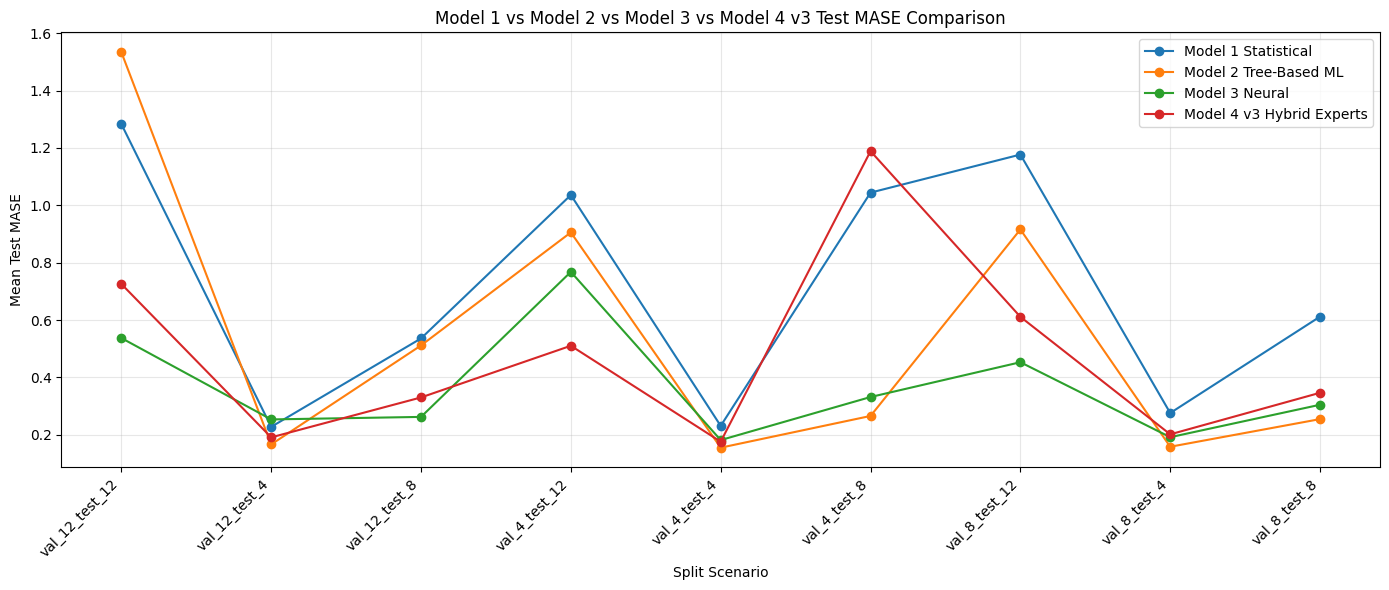

In [18]:
def load_prior_results(path, model_name):
    if not os.path.exists(path):
        print(f'Skipping {model_name}; file not found:', path)
        return None

    df_prior = pd.read_csv(path)

    if 'scenario' not in df_prior.columns and 'scenario_id' in df_prior.columns:
        df_prior = df_prior.rename(columns={'scenario_id': 'scenario'})

    if 'MASE' in df_prior.columns:
        out = df_prior.groupby('scenario', as_index=False)['MASE'].mean().rename(columns={'MASE': 'mean_test_MASE'})
    elif 'mean_test_mase' in df_prior.columns:
        out = df_prior[['scenario', 'mean_test_mase']].rename(columns={'mean_test_mase': 'mean_test_MASE'})
    else:
        print(f'Skipping {model_name}; no MASE column found.')
        return None

    out['model'] = model_name
    return out

comparison_frames = []

for path, name in [
    (MODEL_1_FILE, 'Model 1 Statistical'),
    (MODEL_2_FILE, 'Model 2 Tree-Based ML'),
    (MODEL_3_FILE, 'Model 3 Neural')
]:
    temp = load_prior_results(path, name)
    if temp is not None:
        comparison_frames.append(temp)

m4_comp = test_results_df[['scenario', 'MASE']].rename(columns={'MASE': 'mean_test_MASE'}).copy()
m4_comp['model'] = 'Model 4 v3 Hybrid Experts'
comparison_frames.append(m4_comp)

comparison_df = pd.concat(comparison_frames, ignore_index=True)
comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'model_1_vs_model_2_vs_model_3_vs_model_4_v3_comparison.csv'), index=False, encoding='utf-8-sig')

plt.figure(figsize=(14, 6))
for model_name in comparison_df['model'].unique():
    sub = comparison_df[comparison_df['model'] == model_name].sort_values('scenario')
    plt.plot(sub['scenario'], sub['mean_test_MASE'], marker='o', label=model_name)
plt.title('Model 1 vs Model 2 vs Model 3 vs Model 4 v3 Test MASE Comparison')
plt.xlabel('Split Scenario')
plt.ylabel('Mean Test MASE')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_1_vs_model_2_vs_model_3_vs_model_4_v3_comparison.png'), dpi=150)
plt.show()

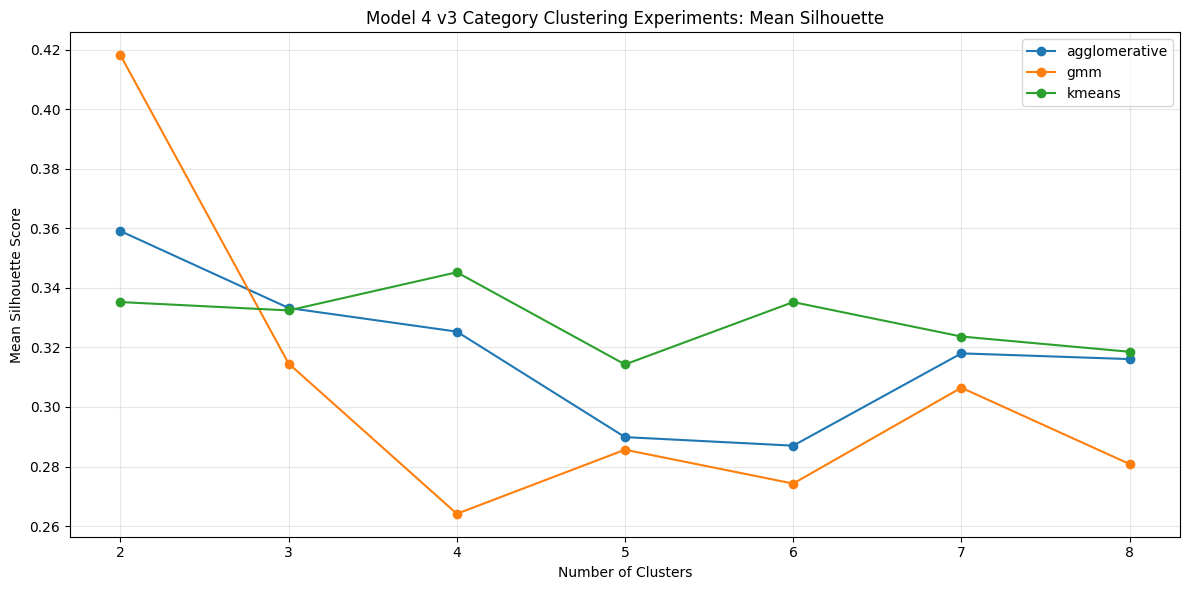

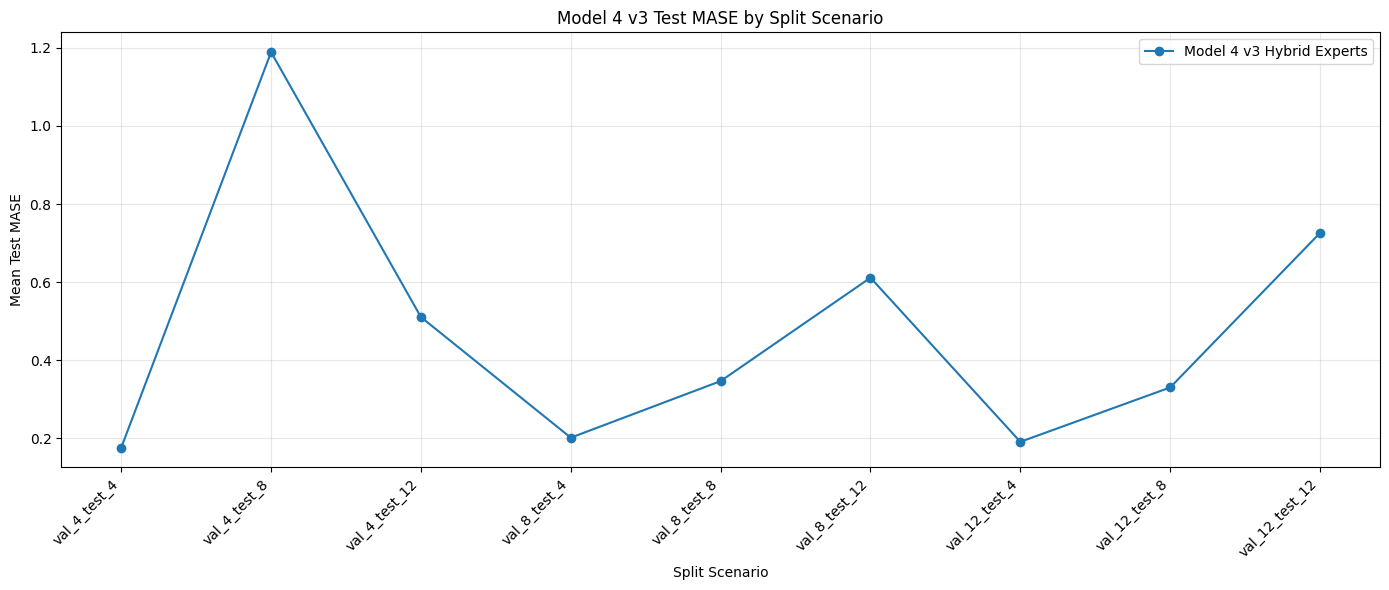

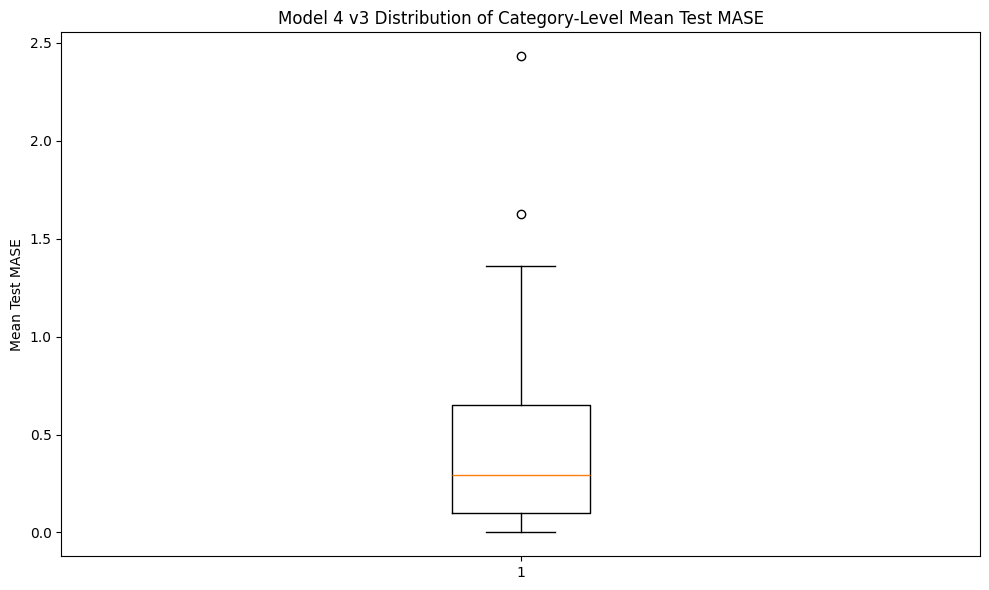

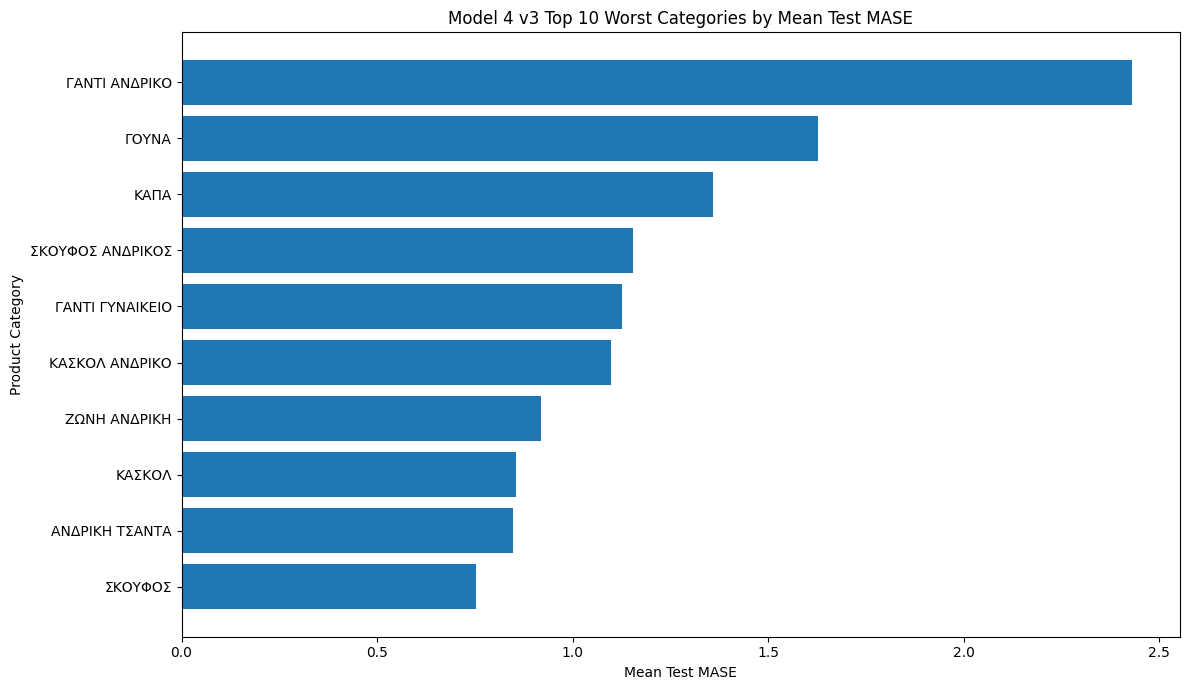

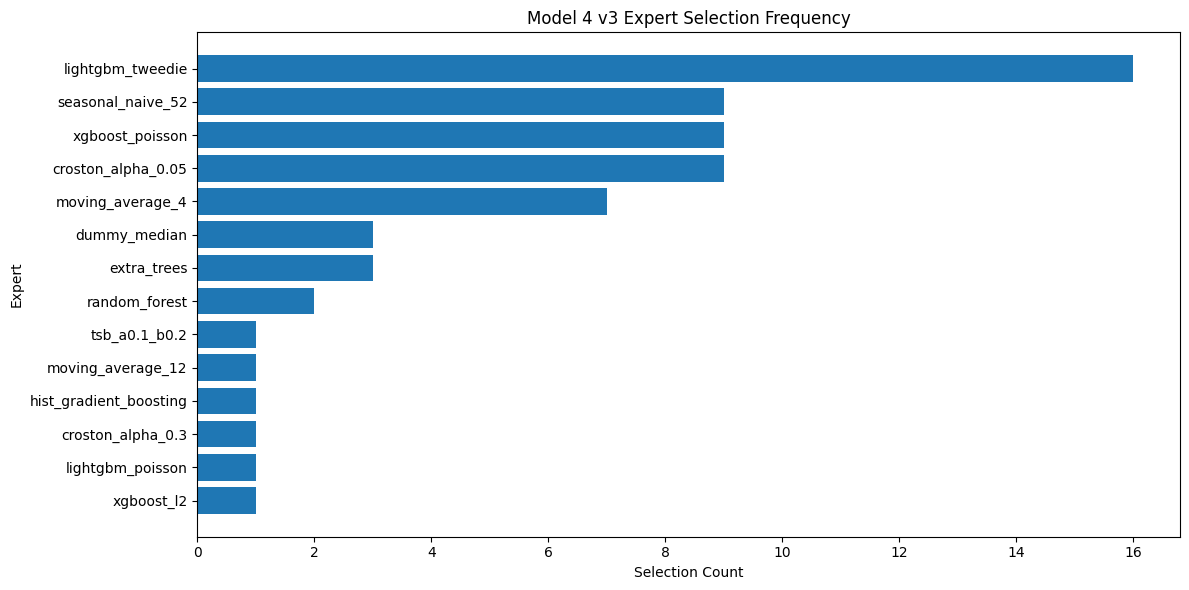

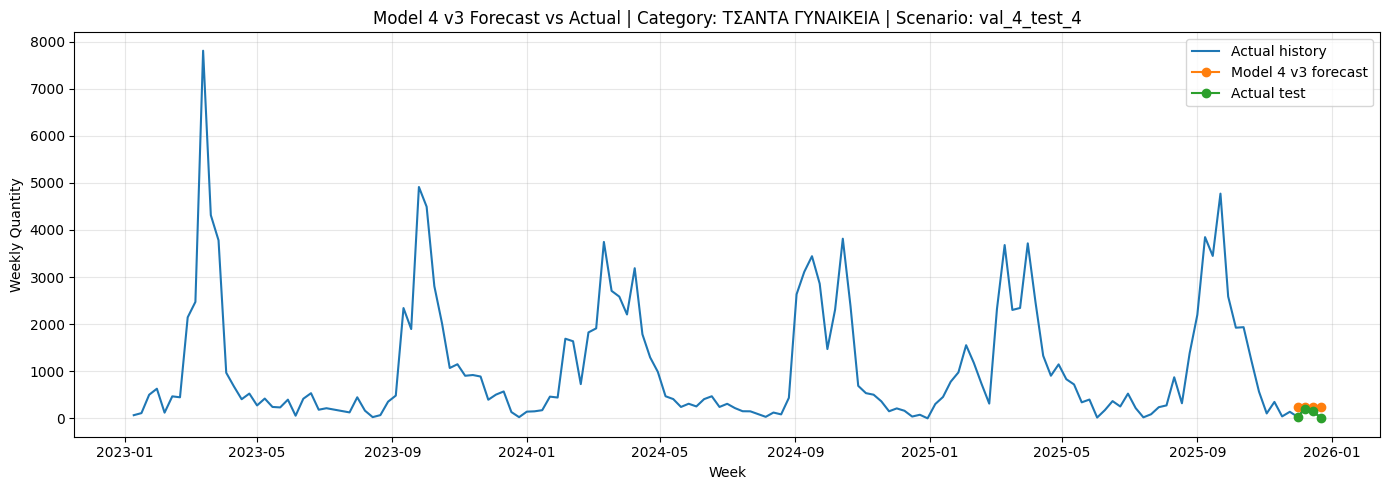

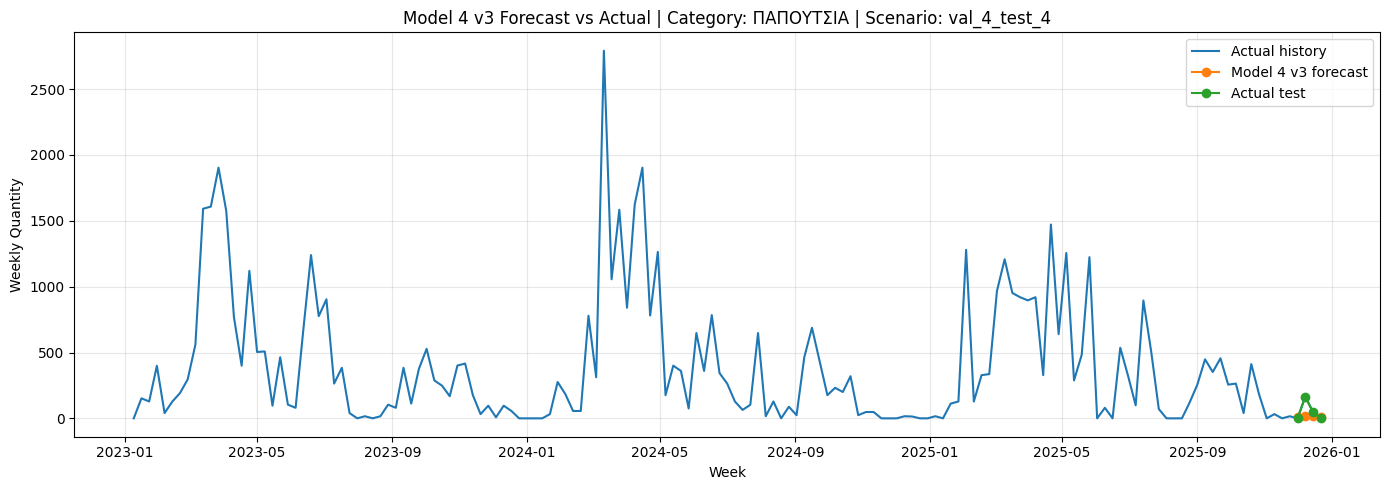

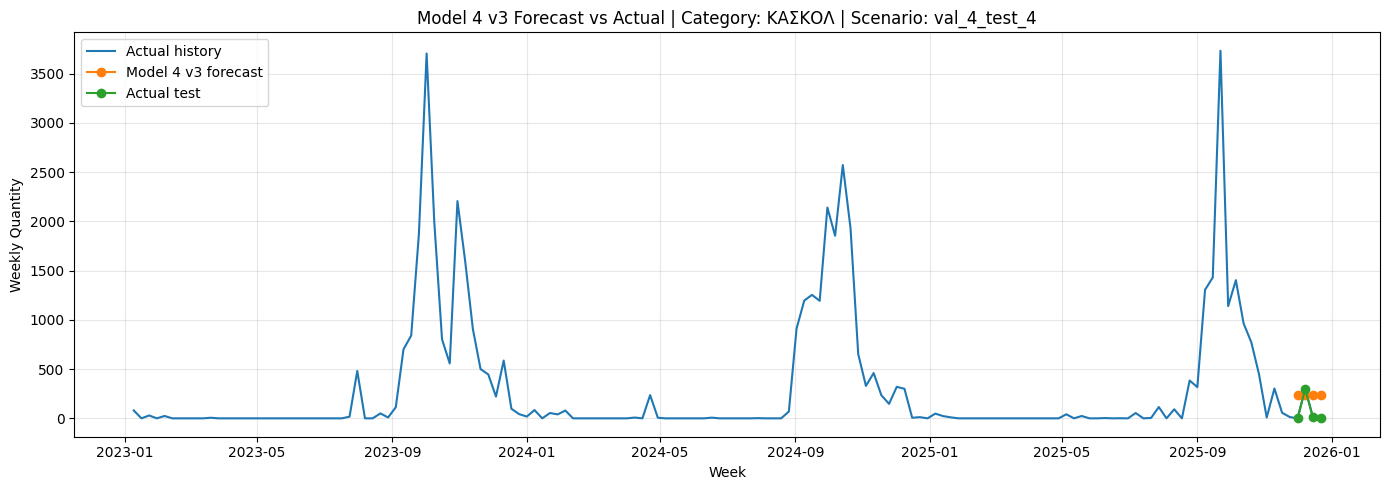

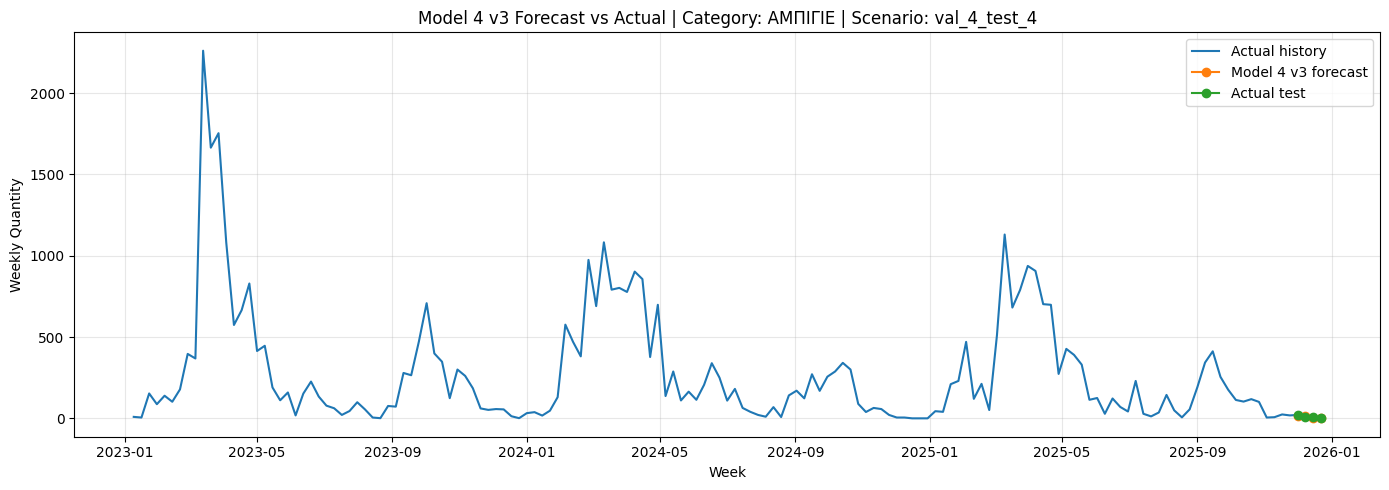

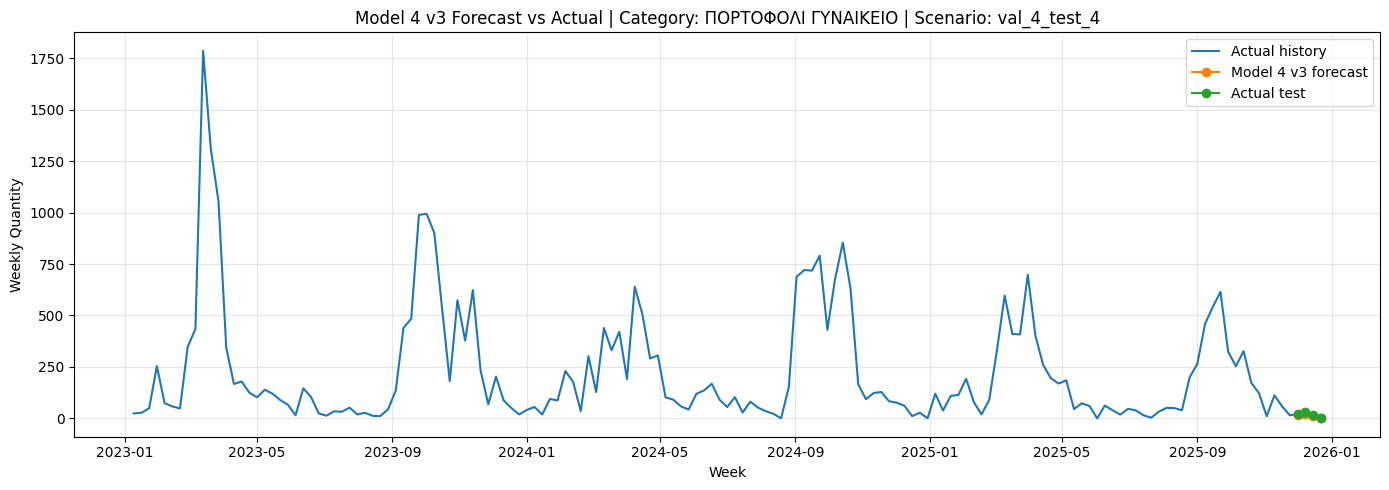

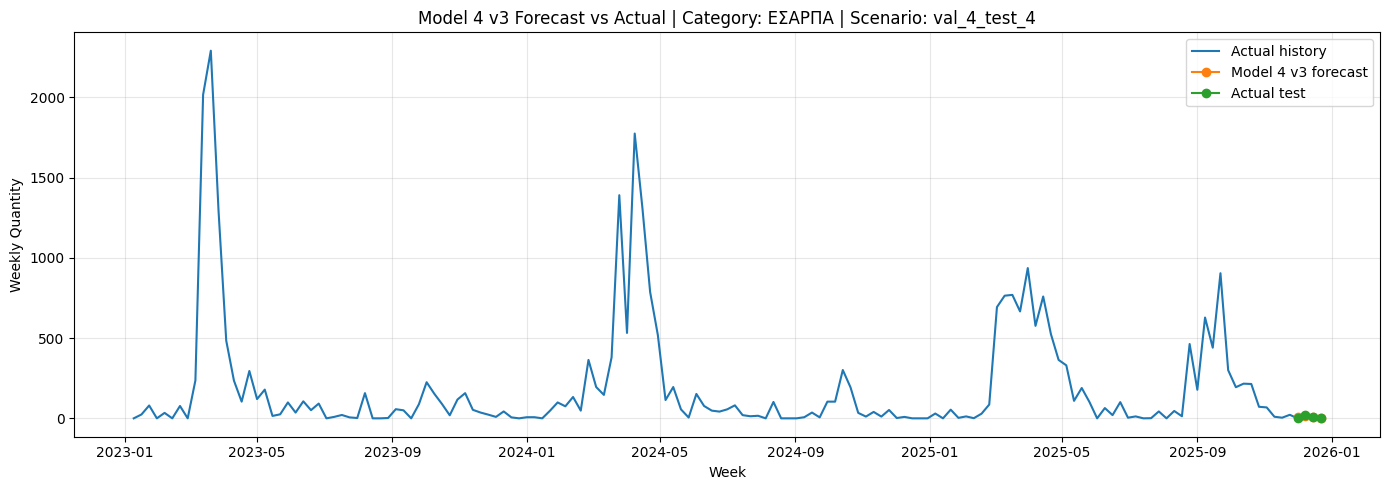

In [19]:
if not clustering_results_all.empty:
    avg_cluster_results = (
        clustering_results_all
        .groupby(['algorithm', 'k'], as_index=False)
        .agg(mean_silhouette=('silhouette', 'mean'))
    )

    plt.figure(figsize=(12, 6))
    for algorithm in avg_cluster_results['algorithm'].unique():
        sub = avg_cluster_results[avg_cluster_results['algorithm'] == algorithm].sort_values('k')
        plt.plot(sub['k'], sub['mean_silhouette'], marker='o', label=algorithm)
    plt.title('Model 4 v3 Category Clustering Experiments: Mean Silhouette')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Mean Silhouette Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_4_v3_clustering_silhouette.png'), dpi=150)
    plt.show()

plt.figure(figsize=(14, 6))
plt.plot(test_results_df['scenario'], test_results_df['MASE'], marker='o', label='Model 4 v3 Hybrid Experts')
plt.title('Model 4 v3 Test MASE by Split Scenario')
plt.xlabel('Split Scenario')
plt.ylabel('Mean Test MASE')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_4_v3_test_mase_by_scenario.png'), dpi=150)
plt.show()

category_mean_metrics = (
    category_metrics_df
    .groupby('Product Category', as_index=False)
    .agg(
        mean_MASE=('MASE', 'mean'),
        median_MASE=('MASE', 'median'),
        mean_MAE=('MAE', 'mean'),
        mean_RMSE=('RMSE', 'mean')
    )
    .sort_values('mean_MASE', ascending=False)
)
category_mean_metrics.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_category_mean_metrics.csv'), index=False, encoding='utf-8-sig')

plt.figure(figsize=(10, 6))
plt.boxplot(category_mean_metrics['mean_MASE'].dropna())
plt.title('Model 4 v3 Distribution of Category-Level Mean Test MASE')
plt.ylabel('Mean Test MASE')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_4_v3_category_mase_distribution.png'), dpi=150)
plt.show()

worst_categories = category_mean_metrics.head(10).sort_values('mean_MASE')
plt.figure(figsize=(12, 7))
plt.barh(worst_categories['Product Category'], worst_categories['mean_MASE'])
plt.title('Model 4 v3 Top 10 Worst Categories by Mean Test MASE')
plt.xlabel('Mean Test MASE')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_4_v3_worst_categories_mase.png'), dpi=150)
plt.show()

if not best_experts_df.empty:
    expert_counts = best_experts_df['expert_name'].value_counts().reset_index()
    expert_counts.columns = ['expert_name', 'selection_count']
    expert_counts.to_csv(os.path.join(OUTPUT_DIR, 'model_4_v3_expert_selection_counts.csv'), index=False, encoding='utf-8-sig')

    plt.figure(figsize=(12, 6))
    plt.barh(expert_counts['expert_name'], expert_counts['selection_count'])
    plt.gca().invert_yaxis()
    plt.title('Model 4 v3 Expert Selection Frequency')
    plt.xlabel('Selection Count')
    plt.ylabel('Expert')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'plot_model_4_v3_expert_selection_frequency.png'), dpi=150)
    plt.show()

if not predictions_df.empty:
    selected_scenario = test_results_df.sort_values('MASE').iloc[0]['scenario']
    top_categories = (
        category_panel.groupby('Product Category', as_index=False)['weekly_quantity']
        .sum()
        .sort_values('weekly_quantity', ascending=False)
        .head(6)['Product Category'].tolist()
    )

    for category in top_categories:
        hist = category_panel[category_panel['Product Category'] == category].sort_values('week_start')
        pred = predictions_df[
            (predictions_df['scenario'] == selected_scenario) &
            (predictions_df['Product Category'] == category)
        ].sort_values('week_start')

        if pred.empty:
            continue

        plt.figure(figsize=(14, 5))
        plt.plot(hist['week_start'], hist['weekly_quantity'], label='Actual history')
        plt.plot(pred['week_start'], pred['prediction'], marker='o', label='Model 4 v3 forecast')
        plt.plot(pred['week_start'], pred['weekly_quantity'], marker='o', label='Actual test')
        plt.title(f'Model 4 v3 Forecast vs Actual | Category: {category} | Scenario: {selected_scenario}')
        plt.xlabel('Week')
        plt.ylabel('Weekly Quantity')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_category = str(category).replace('/', '_').replace(' ', '_')
        plt.savefig(os.path.join(OUTPUT_DIR, f'plot_model_4_v3_forecast_vs_actual_{safe_category}.png'), dpi=150)
        plt.show()

In [20]:
experiment_log = {
    'run_timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model': 'Model 4 v3 - Category-Level Cluster-Based Hybrid Expert Forecasting',
    'data_file': DATA_FILE,
    'output_dir': OUTPUT_DIR,
    'forecasting_level': 'Product Category',
    'clustering_level': 'Product Category behavioral profile',
    'clustering_features': CLUSTER_FEATURE_COLS,
    'clustering_algorithms': ['kmeans', 'agglomerative', 'gmm'],
    'expert_families': list(get_all_experts().keys()),
    'selection_rule': 'For each scenario and category cluster, select expert with lowest validation MASE; final test evaluated once only after selection.',
    'leakage_control': [
        'Category behavioral clustering profiles are built using training data only for each split scenario.',
        'Forecasting features are lagged/shifted and do not include current-period target leakage.',
        'Validation is used for expert selection; test is not used for tuning.'
    ]
}

with open(os.path.join(OUTPUT_DIR, 'model_4_v3_experiment_log.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_log, f, ensure_ascii=False, indent=2)

print('\nFinal checks')
print('Scenarios evaluated:', test_results_df['scenario'].nunique())
print('Mean Model 4 v3 MASE:', test_results_df['MASE'].mean())
print('Median Model 4 v3 MASE:', test_results_df['MASE'].median())
print('Prediction rows:', len(predictions_df))
print('Output directory:', OUTPUT_DIR)

if predictions_df.empty:
    raise ValueError('No predictions generated.')
if predictions_df['prediction'].isna().any():
    raise ValueError('NaN predictions detected.')
if (predictions_df['prediction'] < 0).any():
    raise ValueError('Negative predictions detected.')

print('\nModel 4 v3 completed successfully.')


Final checks
Scenarios evaluated: 9
Mean Model 4 v3 MASE: 0.4759696778923581
Median Model 4 v3 MASE: 0.34676795746570477
Prediction rows: 2880
Output directory: /content/drive/MyDrive/model_4_v3_hybrid_expert_outputs

Model 4 v3 completed successfully.
